In [1]:
import os

# ============================================================================
# RESOURCE ALLOCATION CONFIGURATION FOR PARALLEL NOTEBOOK EXECUTION
# ============================================================================

# --- CPU Threading Configuration ---
# Set the number of threads for parallel operations
os.environ['OMP_NUM_THREADS'] = '8'  # OpenMP threads
os.environ['MKL_NUM_THREADS'] = '8'  # Intel MKL threads
os.environ['NUMEXPR_NUM_THREADS'] = '8'  # NumExpr threads
os.environ['OPENBLAS_NUM_THREADS'] = '8'  # OpenBLAS threads

# --- PyTorch Threading Configuration ---
# Allow PyTorch to use multiple CPU threads for intra-op parallelism
os.environ['TORCH_NUM_THREADS'] = '8'

# --- CUDA Configuration ---
# Disable blocking for better GPU utilization when running multiple notebooks
os.environ['CUDA_LAUNCH_BLOCKING'] = '0'
os.environ['TORCH_USE_CUDA_DSA'] = '1'
os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'  # Increased workspace size

# Enable CUDA caching allocator for faster memory allocation
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'max_split_size_mb:512'

# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from rdkit import Chem
from rdkit.Chem import Descriptors
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GINEConv
from torch_geometric.nn.aggr import AttentionalAggregation
from torch_geometric.data import Batch
import torch_geometric
import json
from matplotlib import rc
import matplotlib as mpl
from scipy.stats import gaussian_kde
import random
import seaborn as sns
from matplotlib.ticker import MaxNLocator, ScalarFormatter, MultipleLocator, AutoMinorLocator
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from datetime import datetime
import shap
import numpy as np

In [2]:
print(f"Torch Geometric version: {torch_geometric.__version__}")
torch.backends.cudnn.benchmark = True  # Auto-tune convolution algorithms
torch.backends.cuda.matmul.allow_tf32 = True  # Use TF32 on Ampere+ GPUs
torch.backends.cudnn.allow_tf32 = True
torch.set_num_threads(8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
os.makedirs("checkpoints", exist_ok=True)

SEED = 10
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
g = torch.Generator()
g.manual_seed(SEED)

# Make cuDNN deterministic
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True)

def _worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

print(f"Deterministic seed set to: {SEED}")

Torch Geometric version: 2.7.0
Using device: cuda
Deterministic seed set to: 10


In [3]:
# 1. Load Data
df = pd.read_excel('dataset/V1.xlsx')
component_cols = ['comp1_blockA_type', 'comp1_blockB_type', 'comp2_blockA_type', 'comp2_blockB_type', 'solv_1', 'solv_2','add_type']
df[component_cols] = df[component_cols].fillna('')

# Analyze unique SMILES in each component
print("Unique SMILES per component:")
unique_counts = {}
for col in component_cols:
    unique_vals = df.loc[df[col] != '', col].unique()
    unique_counts[col] = len(unique_vals)
    print(f"- {col}: {len(unique_vals)} unique molecules, they are {unique_vals.tolist()}")

all_vals = pd.unique(df[component_cols].values.ravel('K'))
filtered_smiles = [s for s in all_vals if isinstance(s, str) and s.strip() != '']
ignored_entries = [v for v in all_vals if v not in filtered_smiles]

total_unique = len(filtered_smiles)

print(f"\nTotal unique SMILES across all columns: {total_unique}")
print("Filtered unique SMILES:", filtered_smiles)

Unique SMILES per component:
- comp1_blockA_type: 1 unique molecules, they are ['CCc1ccccc1']
- comp1_blockB_type: 2 unique molecules, they are ['CCO', 'Cc1ccccn1']
- comp2_blockA_type: 1 unique molecules, they are ['CCc1ccccc1']
- comp2_blockB_type: 1 unique molecules, they are ['Cc1ccccn1']
- solv_1: 1 unique molecules, they are ['Cc1ccccc1']
- solv_2: 1 unique molecules, they are ['C1CCOC1']
- add_type: 2 unique molecules, they are ['Clc1cccc2ccccc12', 'Cc1cccc2ccccc12']

Total unique SMILES across all columns: 7
Filtered unique SMILES: ['CCc1ccccc1', 'CCO', 'Cc1ccccn1', 'Cc1ccccc1', 'C1CCOC1', 'Clc1cccc2ccccc12', 'Cc1cccc2ccccc12']


In [4]:
def smiles_to_graph(smiles):
    """
    Converts a SMILES string to a PyTorch Geometric Data object with richer atom/bond features.
    """
    if pd.isna(smiles):
        return None
    
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),                     # atomic number
            atom.GetTotalDegree(),                   # degree : Number of directly bonded neighbors (including implicit Hs)
            int(atom.GetHybridization()),            # hybridization (as int enum)
            int(atom.GetIsAromatic()),               # aromatic
            atom.GetTotalNumHs(),                    # total Hs
            int(atom.IsInRing()),                    # in ring flag
            atom.GetMass(),                          # atomic mass
        ])
    x = torch.tensor(atom_features, dtype=torch.float)

    # Bond features: [bond_type, conjugated, in_ring]
    bond_type_map = {
        Chem.rdchem.BondType.SINGLE: 0,
        Chem.rdchem.BondType.DOUBLE: 1,
        Chem.rdchem.BondType.TRIPLE: 2,
        Chem.rdchem.BondType.AROMATIC: 3
    }

    edge_indices = []
    edge_attrs = []

    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        b_type = bond_type_map.get(bond.GetBondType(), 4)
        conjugated = int(bond.GetIsConjugated())
        in_ring = int(bond.IsInRing())

        # Add bidirectional edges
        edge_indices.append((start, end))
        edge_indices.append((end, start))

        edge_attrs.append([b_type, conjugated, in_ring])
        edge_attrs.append([b_type, conjugated, in_ring])

    if len(edge_indices) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, 3), dtype=torch.float)
    else:
        edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()
        edge_attr = torch.tensor(edge_attrs, dtype=torch.float)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr)

# Test with a sample SMILES
test_smiles = df['comp1_blockA_type'].dropna().iloc[0]
print(f"Testing SMILES: {test_smiles}")
graph = smiles_to_graph(test_smiles)
print(graph)
print("Node feature dim:", graph.x.shape[1], "Edge attr dim:", graph.edge_attr.shape[1] if graph.edge_attr is not None else None)

# A. Build Molecular Library
all_smiles = pd.unique(df[['comp1_blockA_type', 'comp1_blockB_type', 'comp2_blockA_type', 'comp2_blockB_type', 'solv_1', 'solv_2', 'add_type']].values.ravel('K'))
# Remove NaN and empty-string entries 
all_smiles = [s for s in all_smiles if isinstance(s, str) and s.strip() != '']

# Map SMILES to an integer ID
smiles_to_idx = {s: i for i, s in enumerate(all_smiles)}
print(f"Vocabulary Size: {len(smiles_to_idx)}")

# Pre-compute graphs for the library
molecular_graphs = []
for s in all_smiles:
    molecular_graphs.append(smiles_to_graph(s))

print("Pre-computed molecular graphs.")

Testing SMILES: CCc1ccccc1
Data(x=[8, 7], edge_index=[2, 16], edge_attr=[16, 3])
Node feature dim: 7 Edge attr dim: 3
Vocabulary Size: 7
Pre-computed molecular graphs.


In [5]:
class PolymerDataset(Dataset):
    def __init__(self, dataframe, target_cols=['gisaxs_domain', 'gisaxs_fwhm'], target_scaler=None):
        self.df = dataframe.reset_index(drop=True)
        self.target_cols = target_cols
        
        # Nodes: 0:Comp1_BlockA, 1:Comp1_BlockB, 2:Comp2_BlockA, 3:Comp2_BlockB, 4:Solv1, 5:Solv2, 6:Add
        self.comp_cols = ['comp1_blockA_type', 'comp1_blockB_type','comp2_blockA_type', 'comp2_blockB_type', 'solv_1', 'solv_2', 'add_type']

        self.node_features = self._prepare_node_features()
        self.smiles_indices = self._prepare_smiles_indices()

        raw_targets = self.df[self.target_cols].apply(pd.to_numeric, errors='coerce').values.astype(np.float32)
        # Apply log transformation
        raw_targets = np.log1p(raw_targets)
        
        if target_scaler is None:
            self.target_scaler = StandardScaler()
            self.targets = self.target_scaler.fit_transform(raw_targets).astype(np.float32)
        else:
            self.target_scaler = target_scaler
            self.targets = self.target_scaler.transform(raw_targets).astype(np.float32)

    def _prepare_smiles_indices(self):
        indices = np.full((len(self.df), 7), -1, dtype=int)
        for i, col in enumerate(self.comp_cols):
            col_series = self.df[col].replace('', np.nan).map(smiles_to_idx).fillna(-1).astype(int).values   #smiles_to_idx is from above cell
            indices[:, i] = col_series
        return torch.tensor(indices, dtype=torch.long)

    def inverse_targets(self, y_scaled):
        """Inverse transform scaled targets back to original units."""
        y_unscaled = self.target_scaler.inverse_transform(y_scaled)
        return np.expm1(y_unscaled) 

    def _prepare_node_features(self):
        """
        Prepare per-node features for the 7 component nodes:
        """
        N = len(self.df)
        features = np.zeros((N, 7, 2), dtype=np.float32)

        # 1. Molecular weights 
        def get_mw_values(col_name):
            values = self.df[col_name].fillna(0).values.copy() if col_name in self.df.columns else np.zeros(N)
            if 'comp' in col_name:  
                values *= 1000
            return values
        
        def smiles_mw_or_zero(smiles):
            if not isinstance(smiles, str) or smiles.strip() == '':
                return 0.0
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                return 0.0
            try:
                return Descriptors.MolWt(mol)
            except:
                return 0.0

        mw_Comp1BlockA = get_mw_values('comp1_blockA_MW')
        mw_Comp1BlockB = get_mw_values('comp1_blockB_MW')
        mw_Comp2BlockA = get_mw_values('comp2_blockA_MW')
        mw_Comp2BlockB = get_mw_values('comp2_blockB_MW')
        mw_solv1 = self.df['solv_1'].apply(smiles_mw_or_zero).values
        mw_solv2 = self.df['solv_2'].apply(smiles_mw_or_zero).values
        mw_add = self.df['add_type'].apply(smiles_mw_or_zero).values
        features[:, 0, 0] = mw_Comp1BlockA
        features[:, 1, 0] = mw_Comp1BlockB
        features[:, 2, 0] = mw_Comp2BlockA
        features[:, 3, 0] = mw_Comp2BlockB
        features[:, 4, 0] = mw_solv1
        features[:, 5, 0] = mw_solv2
        features[:, 6, 0] = mw_add
        features[:, :, 0] = np.log1p(features[:, :, 0])           #Apply log1p for MWts

        #2. component fractions 
        comp1_frac = self.df.get('comp1_frac', pd.Series(0, index=self.df.index)).astype(float).values
        has_C1blockA = self.df['comp1_blockA_type'].notna() & (self.df['comp1_blockA_type'] != '')
        has_C1blockB = self.df['comp1_blockB_type'].notna() & (self.df['comp1_blockB_type'] != '')
        features[:, 0, 1] = np.where(has_C1blockA,  np.where(has_C1blockB, comp1_frac / 2, comp1_frac), 0.0)  # BlockA fraction
        features[:, 1, 1] = np.where(has_C1blockB,  np.where(has_C1blockA, comp1_frac / 2, comp1_frac),  0.0)  # BlockB fraction
        
        comp2_frac_total = 1.0 - comp1_frac
        has_comp2_blockA = self.df['comp2_blockA_type'].notna() & (self.df['comp2_blockA_type'] != '')
        has_comp2_blockB = self.df['comp2_blockB_type'].notna() & (self.df['comp2_blockB_type'] != '')
        features[:, 2, 1] = np.where(has_comp2_blockA, np.where(has_comp2_blockB, comp2_frac_total / 2, comp2_frac_total), 0.0)  # Comp2 BlockA
        features[:, 3, 1] = np.where(has_comp2_blockB,np.where(has_comp2_blockA, comp2_frac_total / 2, comp2_frac_total),  0.0)  

        #Solvent ratio
        solv_ratio = self.df.get('solv_ratio', pd.Series(0, index=self.df.index)).fillna(0).astype(float).values
        features[:, 4, 1] = solv_ratio
        features[:, 5, 1] = np.where(self.df['solv_2'] != '', (1.0 - solv_ratio), 0.0)

        #Additive ratio
        features[:, 6, 1] = self.df.get('add_ratio', pd.Series(0, index=self.df.index)).fillna(0).astype(float).values
        return torch.tensor(features, dtype=torch.float)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        s_idx = self.smiles_indices[idx]
        node_scalar_feat = self.node_features[idx]
        y = torch.tensor(self.targets[idx], dtype=torch.float)
        return s_idx, node_scalar_feat, y 
    
# Create dataset
dataset = PolymerDataset(df)
print(f"Total samples: {len(dataset)}")

Total samples: 719


In [6]:
class MoleculeGNN(nn.Module):
    """
    GNN:
    1. Uses GINEConv to leverage bond features (edge_attr).
    2. Uses Batch Normalization.
    """
    def __init__(self, num_atom_features, num_edge_features, hidden_dim=64, out_dim=64):
        super().__init__()
        
        self.atom_projections = nn.Linear(num_atom_features, hidden_dim)
        self.bond_projections = nn.Linear(num_edge_features, hidden_dim)
        
        self.conv1 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), 
                nn.BatchNorm1d(hidden_dim), 
                nn.GELU(),
                nn.Linear(hidden_dim, hidden_dim)
            ), edge_dim=hidden_dim)
        
        self.conv2 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), 
                nn.BatchNorm1d(hidden_dim), 
                nn.GELU(),
                nn.Linear(hidden_dim, hidden_dim)
            ), edge_dim=hidden_dim)
        
        self.conv3 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim), 
                nn.BatchNorm1d(hidden_dim), 
                nn.GELU(),
                nn.Linear(hidden_dim, out_dim)
            ), edge_dim=hidden_dim)
        self.attention_pool = AttentionalAggregation(gate_nn=nn.Sequential(nn.Linear(out_dim, 1)))
        
    def forward(self, x, edge_index, edge_attr, batch):
        x = self.atom_projections(x)
        edge_attr = self.bond_projections(edge_attr)
        x = self.conv1(x, edge_index, edge_attr=edge_attr)
        x = x.relu()
        x = self.conv2(x, edge_index, edge_attr=edge_attr)
        x = x.relu()
        x = self.conv3(x, edge_index, edge_attr=edge_attr)
        out = self.attention_pool(x, batch)
        return out

class HierarchicalGNN(nn.Module):
    def __init__(self, molecular_graphs, num_atom_feat, num_edge_feat=3, mol_embed_dim=64, hidden_dim=64, processing_feature_dim=2, num_components=7, dropout_rate=0.1):
        super().__init__()
        
        self.dropout_rate = dropout_rate
        self.mol_gnn = MoleculeGNN(num_atom_feat, num_edge_feat, hidden_dim, mol_embed_dim)
        self.molecular_graphs_list = molecular_graphs
        self.mol_out_dim = mol_embed_dim 

        # 4. Component Level Input
        self.process_feature_dim = processing_feature_dim
        self.comp_input_dim = self.mol_out_dim + self.process_feature_dim
        
        self.comp_encoder = nn.Sequential(
            nn.Linear(self.comp_input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU()
        )
        
        self.role_embedding = nn.Embedding(num_components, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(d_model=hidden_dim, nhead=4, dim_feedforward=hidden_dim*2, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        # 5. Global Level
        self.num_components = num_components
        self.passthrough_dim = self.num_components * self.process_feature_dim
        self.global_input_dim = (self.num_components * hidden_dim) + self.passthrough_dim 

        # Backbone
        self.backbone = nn.Sequential(
            nn.Linear(self.global_input_dim, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(self.dropout_rate),
            nn.Linear(hidden_dim * 2, hidden_dim * 2),
            nn.BatchNorm1d(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(self.dropout_rate)
        )
        # Residual connection: project input to output dim
        self.residual_proj = nn.Linear(self.global_input_dim, hidden_dim * 2)
        
        self.tower_domain = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )

        self.tower_fwhm = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
    def _get_molecular_embeddings(self):
        graphs_on_device = [g.to(device) for g in self.molecular_graphs_list]
        batch_data = Batch.from_data_list(graphs_on_device)
        return self.mol_gnn(batch_data.x, batch_data.edge_index, batch_data.edge_attr, batch_data.batch)

    def forward(self, s_idx, processing_features, global_scalars=None, mc_dropout=False, return_embeddings=False):
        # Enable dropout during inference if mc_dropout=True
        if mc_dropout:
            self.train()
        batch_size = s_idx.size(0)
        unique_mol_embeds = self._get_molecular_embeddings()
        zero_vec_mol = torch.zeros(1, unique_mol_embeds.size(1), device=device)
        lookup_mol = torch.cat([unique_mol_embeds, zero_vec_mol], dim=0)
        lookup_idx = s_idx.clone()
        lookup_idx[lookup_idx == -1] = len(unique_mol_embeds)
        
        mol_features = lookup_mol[lookup_idx] 
        
        comp_features = torch.cat([mol_features, processing_features], dim=2)
        x = self.comp_encoder(comp_features.view(-1, self.comp_input_dim))
        x = x.view(batch_size, self.num_components, -1)
        
        # Role Embeddings
        role_indices = torch.arange(self.num_components, device=device).unsqueeze(0).expand(batch_size, -1)
        x = x + self.role_embedding(role_indices)
        
        x = self.transformer(x)
        x_flat = x.view(batch_size, -1)
        
        processing_features_flat = processing_features.view(batch_size, -1)
        
        # Concatenate: TransformerContext + Scalars
        out = torch.cat([x_flat, processing_features_flat], dim=1)
        shared_feat = self.backbone(out) + self.residual_proj(out)
        if return_embeddings:
            return shared_feat
        domain_pred = self.tower_domain(shared_feat)
        fwhm_pred = self.tower_fwhm(shared_feat)
        return torch.cat([domain_pred, fwhm_pred], dim=1)

In [7]:
def train(model, loader, optimizer, criterion, fwhm_weight=1.0):
    model.train()
    total_loss = 0
    for s_idx, node_feat, y in loader:
        s_idx = s_idx.to(device)
        node_feat = node_feat.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        out = model(s_idx, node_feat)
        
        loss_domain = criterion(out[:, 0], y[:, 0])
        loss_fwhm = criterion(out[:, 1], y[:, 1])
        
        loss = loss_domain + (fwhm_weight * loss_fwhm)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, criterion, fwhm_weight=1.0):
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for s_idx, node_feat, y in loader:
            s_idx = s_idx.to(device)
            node_feat = node_feat.to(device)
            y = y.to(device)

            out = model(s_idx, node_feat)
            
            loss_domain = criterion(out[:, 0], y[:, 0])
            loss_fwhm = criterion(out[:, 1], y[:, 1])
            loss = loss_domain + (fwhm_weight * loss_fwhm)
            
            total_loss += loss.item()

            all_preds.append(out.cpu().numpy())
            all_labels.append(y.cpu().numpy())

    return total_loss / len(loader), np.concatenate(all_preds), np.concatenate(all_labels)


In [8]:
fwhm_weight = 1.0 
epochs = 200
batch_size = 32

# Build global positional indices once and reuse them everywhere (including AL)
split_labels = df['train/test'].astype(str).str.strip().str.lower()
train_indices_global = np.where(split_labels.values == 'train')[0]
test_indices_global = np.where(split_labels.values == 'test')[0]

train_df = df.iloc[train_indices_global].drop(columns=['train/test']).reset_index(drop=True)
test_df = df.iloc[test_indices_global].drop(columns=['train/test']).reset_index(drop=True)

train_dataset = PolymerDataset(train_df)
test_dataset = PolymerDataset(test_df, target_scaler=train_dataset.target_scaler)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g, worker_init_fn=_worker_init_fn)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, generator=g, worker_init_fn=_worker_init_fn)

print(
    f"Deterministic split created: train={len(train_dataset)}, test={len(test_dataset)}, "
    f"seed={SEED} | global train idx={len(train_indices_global)} | global test idx={len(test_indices_global)}"
)

num_runs = 10
r2_domain_list = []
r2_fwhm_list = []
best_r2_domain = -float('inf')
best_r2_fwhm = -float('inf')
best_model_state = None

# Initialize Model
num_atom_features = 7
num_edge_features = 3

Deterministic split created: train=571, test=143, seed=10 | global train idx=571 | global test idx=143


In [9]:
os.makedirs("full_data_runsV2", exist_ok=True)
model_states = []  # Store all model states
for run in range(num_runs):
    print(f"\n--- Run {run + 1}/{num_runs} ---") 
    model = HierarchicalGNN(
        molecular_graphs, 
        num_atom_features, 
        num_edge_feat=num_edge_features,
        processing_feature_dim=2, 
        num_components=7,
        hidden_dim=128
    ).to(device)

    # Optimizer & Scheduler
    optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    criterion = nn.MSELoss()
    # Train
    for epoch in range(epochs):
        train_loss = train(model, train_loader, optimizer, criterion, fwhm_weight=fwhm_weight)
        scheduler.step(train_loss)
        if (epoch + 1) % 100 == 0:  
            print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}")
    
    # Evaluate
    test_loss, preds_scaled, labels_scaled = evaluate(model, test_loader, criterion, fwhm_weight=fwhm_weight)
    preds = test_dataset.inverse_targets(preds_scaled)
    labels = test_dataset.inverse_targets(labels_scaled)
    r2_domain = r2_score(labels[:, 0], preds[:, 0])
    r2_fwhm = r2_score(labels[:, 1], preds[:, 1])
    r2_domain_list.append(r2_domain)
    r2_fwhm_list.append(r2_fwhm)
    print(f"Run {run + 1}: R2 Domain: {r2_domain:.4f}, R2 FWHM: {r2_fwhm:.4f}")
    
    # Save each model
    model_path = f"full_data_runsV2/gnn_model_run_{run + 1}_domain_{r2_domain:.4f}_fwhm_{r2_fwhm:.4f}.pt"
    torch.save(model.state_dict(), model_path)
    model_states.append(model.state_dict())
    
    # Track best model
    if r2_fwhm > best_r2_fwhm:
        best_r2_fwhm = r2_fwhm
        best_r2_domain = r2_domain
        best_model_state = model.state_dict()
        best_run = run + 1

# Compute statistics
r2_domain_mean = np.mean(r2_domain_list)
r2_domain_std = np.std(r2_domain_list)
r2_fwhm_mean = np.mean(r2_fwhm_list)
r2_fwhm_std = np.std(r2_fwhm_list)

print("" + "="*50)
print("REPRODUCIBILITY ASSESSMENT (10 runs)")
print(f"R2 Domain: Mean={r2_domain_mean:.4f}, Std={r2_domain_std:.4f}")
print(f"R2 FWHM: Mean={r2_fwhm_mean:.4f}, Std={r2_fwhm_std:.4f}")

# Save R2 scores to CSV
r2_results = pd.DataFrame({
    'run': list(range(1, num_runs + 1)),
    'r2_domain': r2_domain_list,
    'r2_fwhm': r2_fwhm_list
})
r2_results.to_csv('full_data_runsV2/model_scores.csv', index=False)
print(f"\nModel scores saved to: full_data_runs/model_scores.csv")

# Save best model from 10 runs
if best_model_state is not None:
    best_model_path = f"full_data_runsV2/best_gnn_model_run_{best_run}_domain_{best_r2_domain:.4f}_fwhm_{best_r2_fwhm:.4f}.pt"
    torch.save(best_model_state, best_model_path)
    print(f"Best model saved to: {best_model_path}")
    print(f"  Run {best_run}: R2 Domain: {best_r2_domain:.4f}, R2 FWHM: {best_r2_fwhm:.4f}")
else:
    print("No model to save.")



--- Run 1/10 ---
Epoch 100: Train Loss 0.2812
Epoch 200: Train Loss 0.1880
Run 1: R2 Domain: 0.9861, R2 FWHM: 0.8427

--- Run 2/10 ---
Epoch 100: Train Loss 0.2243
Epoch 200: Train Loss 0.2147
Run 2: R2 Domain: 0.9734, R2 FWHM: 0.8355

--- Run 3/10 ---
Epoch 100: Train Loss 0.2453
Epoch 200: Train Loss 0.1965
Run 3: R2 Domain: 0.9333, R2 FWHM: 0.7903

--- Run 4/10 ---
Epoch 100: Train Loss 0.2243
Epoch 200: Train Loss 0.2138
Run 4: R2 Domain: 0.9825, R2 FWHM: 0.8328

--- Run 5/10 ---
Epoch 100: Train Loss 0.2321
Epoch 200: Train Loss 0.2033
Run 5: R2 Domain: 0.9836, R2 FWHM: 0.8451

--- Run 6/10 ---
Epoch 100: Train Loss 0.2408
Epoch 200: Train Loss 0.1725
Run 6: R2 Domain: 0.9839, R2 FWHM: 0.8444

--- Run 7/10 ---
Epoch 100: Train Loss 0.2389
Epoch 200: Train Loss 0.2001
Run 7: R2 Domain: 0.9829, R2 FWHM: 0.8370

--- Run 8/10 ---
Epoch 100: Train Loss 0.2372
Epoch 200: Train Loss 0.1704
Run 8: R2 Domain: 0.9804, R2 FWHM: 0.8346

--- Run 9/10 ---
Epoch 100: Train Loss 0.2499
Epoch 200

In [9]:
def classify(df):
    types = np.full(len(df), '', dtype=object)
    types[df['comp2_blockA_type'].isna() | (df['comp2_blockA_type'] == '')] = 'BCP'
    types[(~df['comp2_blockA_type'].isna() & (df['comp2_blockA_type'] != '')) & (df['comp2_blockB_type'].isna() | (df['comp2_blockB_type'] == ''))] = 'BCP+HP'
    types[(~df['comp2_blockA_type'].isna() & (df['comp2_blockA_type'] != '')) & (~df['comp2_blockB_type'].isna() & (df['comp2_blockB_type'] != ''))] = 'BCP+BCP'
    return types

Loading all 10 models from full_data_runsV2/...
Found 10 models
Loading model 1/10: gnn_model_run_10_domain_0.9818_fwhm_0.8398.pt
Loading model 2/10: gnn_model_run_1_domain_0.9861_fwhm_0.8427.pt
Loading model 3/10: gnn_model_run_2_domain_0.9734_fwhm_0.8355.pt
Loading model 4/10: gnn_model_run_3_domain_0.9333_fwhm_0.7903.pt
Loading model 5/10: gnn_model_run_4_domain_0.9825_fwhm_0.8328.pt
Loading model 6/10: gnn_model_run_5_domain_0.9836_fwhm_0.8451.pt
Loading model 7/10: gnn_model_run_6_domain_0.9839_fwhm_0.8444.pt
Loading model 8/10: gnn_model_run_7_domain_0.9829_fwhm_0.8370.pt
Loading model 9/10: gnn_model_run_8_domain_0.9804_fwhm_0.8346.pt
Loading model 10/10: gnn_model_run_9_domain_0.9812_fwhm_0.8463.pt
Predictions shape: (10, 143, 2)


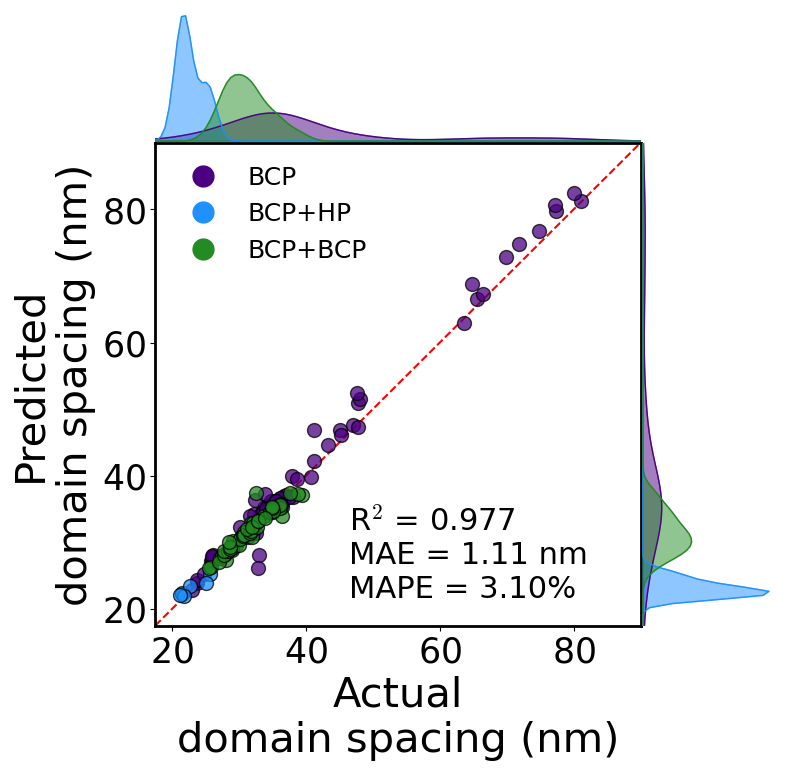

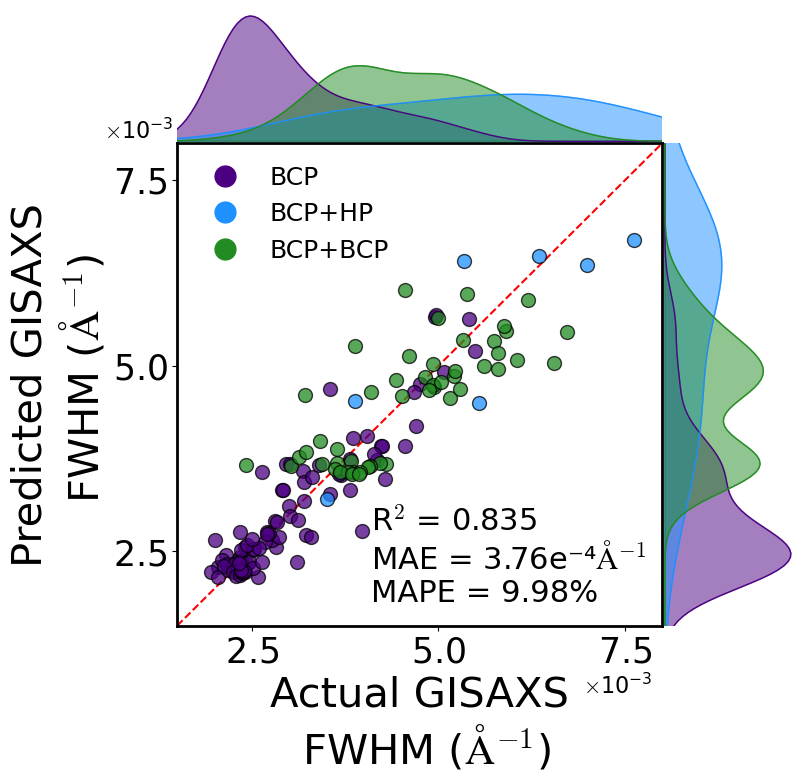

In [10]:
def plot_pred_vs_actual_ensemble(X_test, y_test, y_test_pred_mean, metrics_stats, model_output="model", output_path=None, targets='both', density=True):
    """Optimized plotting function for test data only."""
    
    def superscript(n):
        """Convert number to Unicode superscript."""
        supers = str.maketrans("0123456789-", "⁰¹²³⁴⁵⁶⁷⁸⁹⁻")
        return str(n).translate(supers)
    
    def _plot_single_target(y_test_vals, y_test_pred_vals, target_name, save_suffix, metrics):
        rc('text', usetex=False)
        rc('mathtext', fontset='cm')
        rc('xtick', labelsize=25)
        rc('ytick', labelsize=25)
        rc('axes', labelsize=25, linewidth=2, labelweight='500')
        rc('font', family='sans-serif', size=15, weight='500', style='normal')
        plt.rcParams['axes.spines.right'] = True
        plt.rcParams['axes.spines.top'] = True

        y_test_vals = np.asarray(y_test_vals, dtype=float)
        y_test_pred_vals = np.asarray(y_test_pred_vals, dtype=float)

        fig = plt.figure(figsize=(8, 8))
        gs = fig.add_gridspec(2, 2, width_ratios=[7, 2], height_ratios=[2, 7], hspace=-0.015, wspace=-0.0125)

        ax_main = fig.add_subplot(gs[1, 0])
        ax_top = fig.add_subplot(gs[0, 0])
        ax_right = fig.add_subplot(gs[1, 1])

        # Determine plotting limits
        lim_min = max(min(y_test_vals.min(), y_test_pred_vals.min()), 1e-12)
        lim_max = max(y_test_vals.max(), y_test_pred_vals.max())
        buffer = 0.5 * (lim_max - lim_min) if lim_max > lim_min else 0.5
        lims = [lim_min - buffer, lim_max + buffer]

        # Classify composition types for test data
        test_types = classify(X_test)
        colors = {'BCP': 'indigo', 'BCP+HP': 'dodgerblue', 'BCP+BCP': 'forestgreen'}

        # Plot test data by composition type
        for label, color in colors.items():
            mask = test_types == label
            if np.sum(mask) > 0:
                ax_main.scatter(y_test_vals[mask], y_test_pred_vals[mask], 
                              color=color, edgecolors='black', alpha=0.75, s=100, label=label, zorder=2)

        # Density along X (Actual)
        if density:
            for label, color in colors.items():
                vals = y_test_vals[test_types == label]
                if len(vals) > 1:
                    try:
                        kde = gaussian_kde(vals)
                        x_grid = np.linspace(lims[0], lims[1], 200)
                        density_vals = kde(x_grid)
                        ax_top.plot(x_grid, density_vals, color=color, alpha=0.95, lw=1)
                        ax_top.fill_between(x_grid, 0, density_vals, color=color, alpha=0.5)
                    except Exception:
                        pass

        # Density along Y (Predicted)
        if density:
            for label, color in colors.items():
                vals = y_test_pred_vals[test_types == label]
                if len(vals) > 1:
                    try:
                        kde = gaussian_kde(vals)
                        y_grid = np.linspace(lims[0], lims[1], 200)
                        density_vals = kde(y_grid)
                        ax_right.plot(density_vals, y_grid, color=color, alpha=0.95, lw=1)
                        ax_right.fill_betweenx(y_grid, 0, density_vals, color=color, alpha=0.5)
                    except Exception:
                        pass

        # Aesthetic adjustments
        if target_name == 'domain':
            ax_main.set_xlim(17.5, 90)
            ax_main.set_ylim(17.5, 90)
            ax_top.set_xlim(17.5, 90)
            ax_right.set_ylim(17.5, 90)
        else:  # fwhm
            ax_main.set_xlim(0.0015, 0.008)
            ax_main.set_ylim(0.0015, 0.008)
            ax_top.set_xlim(0.0015, 0.008)
            ax_right.set_ylim(0.0015, 0.008)
            # Set 5 ticks for FWHM axes
            ax_main.locator_params(axis='x', nbins=3)
            ax_main.locator_params(axis='y', nbins=3)

        # Perfect prediction line
        xlim = ax_main.get_xlim()
        ylim = ax_main.get_ylim()
        lim_min = min(xlim[0], ylim[0])
        lim_max = max(xlim[1], ylim[1])
        ax_main.plot([lim_min, lim_max], [lim_min, lim_max], '--', color='red', zorder=0)

        formatter = ScalarFormatter(useMathText=True)
        formatter.set_powerlimits((-2, 3))
        ax_main.xaxis.set_major_formatter(formatter)
        ax_main.yaxis.set_major_formatter(formatter)
        
        # Adjust offset text position and size using coordinates
        ax_main.xaxis.offsetText.set_fontsize(16)
        ax_main.yaxis.offsetText.set_fontsize(16)
        
        if target_name == 'fwhm':
            
             ax_main.xaxis.get_offset_text().set_position((0.98, -0.12))
             ax_main.yaxis.get_offset_text().set_position((-0.15, 0.98))
        else:
             ax_main.xaxis.get_offset_text().set_position((0.98, -0.12))
             ax_main.yaxis.get_offset_text().set_position((-0.15, 0.98))

        if target_name == 'fwhm':
            xlabel = 'Actual GISAXS\n FWHM ($\mathrm{{\AA}}^{{-1}}$)'
            ylabel = 'Predicted GISAXS\n FWHM ($\mathrm{{\AA}}^{{-1}}$)'

        else:
            xlabel = f"Actual\ndomain spacing (nm)"
            ylabel = f"Predicted\ndomain spacing (nm)"

        ax_main.set_xlabel(xlabel, fontsize=30)
        ax_main.set_ylabel(ylabel, fontsize=30)
        ax_main.tick_params(axis='both', which='both', reset=True, top=False, right=False)
        ax_main.set_facecolor('white')
        ax_main.grid(False)

        # Hide density axis ticks
        ax_top.axis('off')
        ax_right.axis('off')

        # Legend
        comp_handles = [Line2D([0], [0], marker='o', color=color, linestyle='None', markersize=10, label=lbl)
                        for lbl, color in colors.items() if np.sum(test_types == lbl) > 0]
        legend = ax_main.legend(handles=comp_handles, fontsize=18, markerscale=1.5, frameon=False, loc='upper left')
        legend.get_frame().set_facecolor('white')

        # Format metrics (mean values only)
        unit_text = '$\mathrm{{\AA}}^{{-1}}$' if target_name == 'fwhm' else ' nm'
        r2_mean = metrics['r2_mean']
        mape_mean = metrics['mape_mean']
        mae_mean = metrics['mae_mean']
        
        mape_str = f"{mape_mean:.2f}"
        if target_name == 'fwhm':
            mantissa, exp = f"{mae_mean:.2e}".split('e')
            mae_str = f"{mantissa}e{superscript(int(exp))}"
        else:
            mae_str = f"{mae_mean:.2e}" if abs(mae_mean) < 1e-2 else f"{mae_mean:.2f}"

        metrics_text = f'R$^2$ = {r2_mean:.3f}\nMAE = {mae_str}{unit_text}\nMAPE = {mape_str}%'
        ax_main.text(0.40, 0.25, metrics_text, transform=ax_main.transAxes,
                     fontsize=22, verticalalignment='top',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0))

        # Axes borders
        for ax in [ax_main, ax_top, ax_right]:
            for spine in ax.spines.values():
                spine.set_color('black')

        # Save figure
        if output_path:
            os.makedirs(output_path, exist_ok=True)
            plt.savefig(f"{output_path}{model_output}_{save_suffix}_parity.pdf", format='pdf',
                        bbox_inches='tight', pad_inches=0, transparent=True)

    # Determine which targets to plot
    target_list = ['domain', 'fwhm'] if targets == 'both' else ([targets] if isinstance(targets, str) else list(targets))

    y_test_vals_all = np.array(y_test)
    y_test_pred_vals_all = np.array(y_test_pred_mean)

    for target in target_list:
        idx = 0 if target == 'domain' else 1
        y_test_vals = y_test_vals_all[:, idx] if y_test_vals_all.ndim == 2 else y_test_vals_all
        y_test_pred_vals = y_test_pred_vals_all[:, idx] if y_test_pred_vals_all.ndim == 2 else y_test_pred_vals_all

        _plot_single_target(y_test_vals, y_test_pred_vals, target, target, metrics_stats[target])


# 2. Load all 10 GNN models and compute metrics for each
print("Loading all 10 models from full_data_runsV2/...")
model_files = sorted([f for f in os.listdir("full_data_runsV2") if f.startswith('gnn_model_run_') and f.endswith('.pt')])
if len(model_files) == 0:
    raise FileNotFoundError("No model files found in 'full_data_runs' directory")

print(f"Found {len(model_files)} models")
num_atom_features = 7
num_edge_features = 3

# Collect predictions and compute metrics from all models
all_preds_test = []
r2_domain_runs = []
r2_fwhm_runs = []
mape_domain_runs = []
mape_fwhm_runs = []
mae_domain_runs = []
mae_fwhm_runs = []
criterion = nn.MSELoss()

for i, model_file in enumerate(model_files):
    model_path = os.path.join("full_data_runsV2", model_file)
    print(f"Loading model {i+1}/{len(model_files)}: {model_file}")

    model = HierarchicalGNN(
        molecular_graphs,
        num_atom_features,
        num_edge_feat=num_edge_features,
        processing_feature_dim=2,
        num_components=7,
        hidden_dim=128,
    ).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=False))
    model.eval()

    with torch.no_grad():
        _, preds_scaled, targets_scaled = evaluate(model, test_loader, criterion, fwhm_weight=fwhm_weight)

    preds = test_dataset.inverse_targets(preds_scaled)
    targets_test = test_dataset.inverse_targets(targets_scaled)
    all_preds_test.append(preds)

    r2_domain_runs.append(r2_score(targets_test[:, 0], preds[:, 0]))
    r2_fwhm_runs.append(r2_score(targets_test[:, 1], preds[:, 1]))

    errors_domain = preds[:, 0] - targets_test[:, 0]
    errors_fwhm = preds[:, 1] - targets_test[:, 1]

    mape_domain = np.mean(np.abs(errors_domain / targets_test[:, 0])) * 100
    mape_fwhm = np.mean(np.abs(errors_fwhm / targets_test[:, 1])) * 100
    mape_domain_runs.append(mape_domain)
    mape_fwhm_runs.append(mape_fwhm)

    mae_domain_runs.append(np.mean(np.abs(errors_domain)))
    mae_fwhm_runs.append(np.mean(np.abs(errors_fwhm)))

all_preds_test = np.array(all_preds_test)
print(f"Predictions shape: {all_preds_test.shape}")
preds_test_mean = np.mean(all_preds_test, axis=0)
metrics_stats = {
    'domain': {
        'r2_mean': np.mean(r2_domain_runs),
        'r2_std': np.std(r2_domain_runs),
        'mape_mean': np.mean(mape_domain_runs),
        'mape_std': np.std(mape_domain_runs),
        'mae_mean': np.mean(mae_domain_runs),
        'mae_std': np.std(mae_domain_runs),
    },
    'fwhm': {
        'r2_mean': np.mean(r2_fwhm_runs),
        'r2_std': np.std(r2_fwhm_runs),
        'mape_mean': np.mean(mape_fwhm_runs),
        'mape_std': np.std(mape_fwhm_runs),
        'mae_mean': np.mean(mae_fwhm_runs),
        'mae_std': np.std(mae_fwhm_runs),
    },
}


# 3. Plot with metrics statistics (test data only)
plot_pred_vs_actual_ensemble(
    X_test=test_df,
    y_test=targets_test,
    y_test_pred_mean=preds_test_mean,
    metrics_stats=metrics_stats,
    model_output="GNN_Ensemble_10runs",
    output_path="results/",
    targets='both',
)
plt.show()

In [11]:
df2 = pd.read_excel('dataset/V2.xlsx')
component_cols = ['comp1_blockA_type', 'comp1_blockB_type','comp2_blockA_type', 'comp2_blockB_type', 'solv_1', 'solv_2', 'add_type']
df2[component_cols] = df2[component_cols].fillna('')
# Extract all unique SMILES from V2 data
v2_component_cols = ['comp1_blockA_type', 'comp1_blockB_type', 'comp2_blockA_type', 'comp2_blockB_type', 'solv_1', 'solv_2', 'add_type']
v2_all_smiles = pd.unique(df2[v2_component_cols].values.ravel('K'))
v2_all_smiles = [s for s in v2_all_smiles if isinstance(s, str) and s.strip() != '']
v2_all_smiles_set = set(v2_all_smiles)
v1_all_smiles_set = set(all_smiles)
new_smiles_in_v2 = v2_all_smiles_set - v1_all_smiles_set
common_smiles = v1_all_smiles_set & v2_all_smiles_set
if len(new_smiles_in_v2) > 0:
    print(f"\nNew chemistries found! Building combined molecular library...")
    print(f"New SMILES examples: {list(new_smiles_in_v2)[:5]}")
    
    # Build combined vocabulary (preserve V1 indices, append new V2 SMILES)
    combined_smiles = list(all_smiles) + list(new_smiles_in_v2)
    combined_smiles_to_idx = {s: i for i, s in enumerate(combined_smiles)}
    
    print(f"\nCombined vocabulary size: {len(combined_smiles_to_idx)}")
    print(f"  V1 SMILES: {len(all_smiles)}")
    print(f"  New V2 SMILES: {len(new_smiles_in_v2)}")
    
    # Pre-compute graphs for new V2 SMILES only
    print("\nComputing molecular graphs for combined library...")
    new_v2_graphs = [smiles_to_graph(s) for s in new_smiles_in_v2]
    combined_molecular_graphs = molecular_graphs + new_v2_graphs
    
    print(f"Combined molecular library created with {len(combined_smiles)} SMILES")
    print(f"Molecular graphs: {len(combined_molecular_graphs)}")

else:
    print("\nNo new chemistries in V2. Using original V1 molecular library.")
    combined_smiles_to_idx = smiles_to_idx
    combined_molecular_graphs = molecular_graphs



New chemistries found! Building combined molecular library...
New SMILES examples: ['CN(C)C=O', 'CC(=C)C(=O)OC(C)(C)C', 'CC(=C)C', 'ClC(Cl)Cl', 'C=Cc1ccncc1']

Combined vocabulary size: 15
  V1 SMILES: 7
  New V2 SMILES: 8

Computing molecular graphs for combined library...
Combined molecular library created with 15 SMILES
Molecular graphs: 15


/tmp/ipykernel_1025686/936726023.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col_series = self.df[col].replace('', np.nan).map(self.smiles_to_idx_custom).fillna(-1).astype(int).values
/tmp/ipykernel_1025686/936726023.py:29: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  col_series = self.df[col].replace('', np.nan).map(self.smiles_to_idx_custom).fillna(-1).astype(int).values


V2 dataset created: 10 samples
Scaling Baseline: V1 StandardScaler (Mean: [3.53320057 0.00375615])
  Model 1/10: gnn_model_run_10_domain_0.9818_fwhm_0.8398.pt
  Model 2/10: gnn_model_run_1_domain_0.9861_fwhm_0.8427.pt
  Model 3/10: gnn_model_run_2_domain_0.9734_fwhm_0.8355.pt
  Model 4/10: gnn_model_run_3_domain_0.9333_fwhm_0.7903.pt
  Model 5/10: gnn_model_run_4_domain_0.9825_fwhm_0.8328.pt
  Model 6/10: gnn_model_run_5_domain_0.9836_fwhm_0.8451.pt
  Model 7/10: gnn_model_run_6_domain_0.9839_fwhm_0.8444.pt
  Model 8/10: gnn_model_run_7_domain_0.9829_fwhm_0.8370.pt
  Model 9/10: gnn_model_run_8_domain_0.9804_fwhm_0.8346.pt
  Model 10/10: gnn_model_run_9_domain_0.9812_fwhm_0.8463.pt
First 10 V2 ensemble predictions (domain, fwhm):
[[2.7161428e+01 4.8831156e-03]
 [2.9628000e+01 4.5076008e-03]
 [6.4579659e+01 1.8613236e-03]
 [6.3987041e+01 1.7672109e-03]
 [7.0025131e+01 1.8522406e-03]
 [6.3418671e+01 1.9081135e-03]
 [6.2877605e+01 1.8178634e-03]
 [6.6544998e+01 1.9622990e-03]
 [5.8238636e

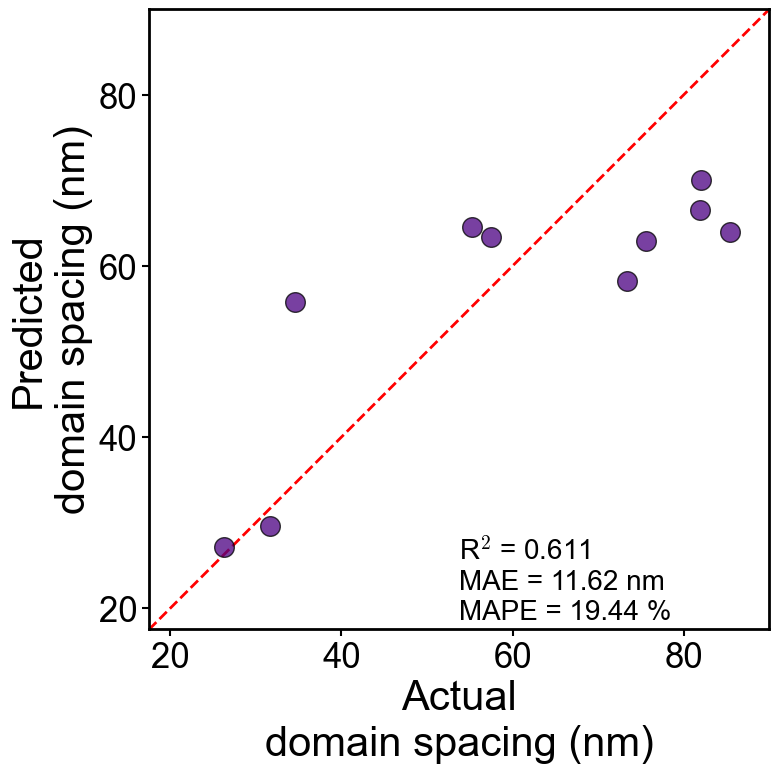

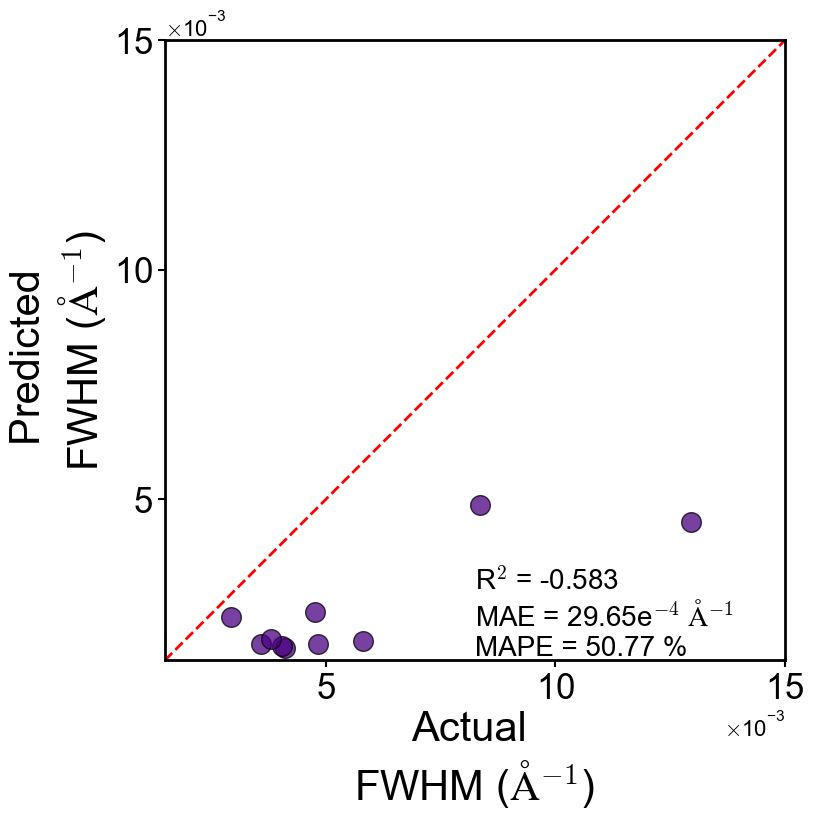

In [13]:

class PolymerDatasetWithCustomVocab(PolymerDataset):
    """Variant that accepts a custom SMILES-to-index mapping for consistent V2 inference."""
    def __init__(self, dataframe, smiles_to_idx_map, target_cols=['gisaxs_domain', 'gisaxs_fwhm'], target_scaler=None, use_v1_scaler=True):
        self.df = dataframe.reset_index(drop=True)
        self.target_cols = target_cols
        self.comp_cols = ['comp1_blockA_type', 'comp1_blockB_type', 'comp2_blockA_type', 'comp2_blockB_type', 'solv_1', 'solv_2', 'add_type']
        self.smiles_to_idx_custom = smiles_to_idx_map

        # Standard processing from base class
        self.node_features = self._prepare_node_features()
        self.smiles_indices = self._prepare_smiles_indices_custom()

        # Targets: Apply log1p and scale
        raw_targets = self.df[self.target_cols].apply(pd.to_numeric, errors='coerce').values.astype(np.float32)
        raw_targets = np.log1p(raw_targets)

        if use_v1_scaler:
            if target_scaler is None:
                raise ValueError("Consistency Error: A target_scaler from V1 must be provided for V2 inference when use_v1_scaler=True.")
            self.target_scaler = target_scaler
            self.targets = self.target_scaler.transform(raw_targets).astype(np.float32)
        else:
            self.target_scaler = StandardScaler()
            self.targets = self.target_scaler.fit_transform(raw_targets).astype(np.float32)

    def _prepare_smiles_indices_custom(self):
        indices = np.full((len(self.df), 7), -1, dtype=int)
        for i, col in enumerate(self.comp_cols):
            col_series = self.df[col].replace('', np.nan).map(self.smiles_to_idx_custom).fillna(-1).astype(int).values
            indices[:, i] = col_series
        return torch.tensor(indices, dtype=torch.long)

dataset_v2 = PolymerDatasetWithCustomVocab(
    df2,
    smiles_to_idx_map=combined_smiles_to_idx,
    target_cols=['gisaxs_domain', 'gisaxs_fwhm'],
    target_scaler=dataset.target_scaler,
    use_v1_scaler=True  # Set to True to use V1 scaler, False to use V2's own scaler
)

print(f"V2 dataset created: {len(dataset_v2)} samples")
if hasattr(dataset_v2, 'target_scaler'):
    scaler_type = "V1 StandardScaler" if dataset_v2.target_scaler is dataset.target_scaler else "V2's own StandardScaler"
    print(f"Scaling Baseline: {scaler_type} (Mean: {dataset_v2.target_scaler.mean_})")

v2_loader = DataLoader(dataset_v2, batch_size=32, shuffle=False)
all_preds_v2 = []
r2_domain_v2_runs, r2_fwhm_v2_runs = [], []
mape_domain_v2_runs, mape_fwhm_v2_runs = [], []
mae_domain_v2_runs, mae_fwhm_v2_runs = [], []

for i, model_file in enumerate(model_files):
    model_path_i = os.path.join("full_data_runsV2", model_file)
    print(f"  Model {i+1}/{len(model_files)}: {model_file}")

    model_v2 = HierarchicalGNN(
        combined_molecular_graphs,
        num_atom_feat=num_atom_features,
        num_edge_feat=num_edge_features,
        processing_feature_dim=2,
        num_components=7,
        hidden_dim=128
    ).to(device)
    model_v2.load_state_dict(torch.load(model_path_i, map_location=device, weights_only=False))
    model_v2.eval()

    with torch.no_grad():
        _, preds_v2_scaled, targets_v2_scaled = evaluate(model_v2, v2_loader, criterion, fwhm_weight=fwhm_weight)

    # Consistent Inverse Transformation
    preds_v2_run = dataset_v2.inverse_targets(preds_v2_scaled)
    targets_v2_run = dataset_v2.inverse_targets(targets_v2_scaled)
    
    all_preds_v2.append(preds_v2_run)

    # Metrics per run
    r2_domain_v2_runs.append(r2_score(targets_v2_run[:, 0], preds_v2_run[:, 0]))
    r2_fwhm_v2_runs.append(r2_score(targets_v2_run[:, 1], preds_v2_run[:, 1]))
    
    err_dom = preds_v2_run[:, 0] - targets_v2_run[:, 0]    
    err_fwhm = preds_v2_run[:, 1] - targets_v2_run[:, 1]
    
    mape_domain_v2 = np.mean(np.abs(errors_domain / targets_test[:, 0])) * 100
    mape_fwhm_v2 = np.mean(np.abs(errors_fwhm / targets_test[:, 1])) * 100
    mape_domain_v2_runs.append(mape_domain_v2)
    mape_fwhm_v2_runs.append(mape_fwhm_v2)

    mae_domain_v2_runs.append(np.mean(np.abs(err_dom)))
    mae_fwhm_v2_runs.append(np.mean(np.abs(err_fwhm)))

all_preds_v2 = np.array(all_preds_v2)
preds_v2_mean = np.mean(all_preds_v2, axis=0)
print("First 10 V2 ensemble predictions (domain, fwhm):")
print(preds_v2_mean[:10])
targets_v2_final = targets_v2_run  
metrics_stats_v2 = {
    'domain': {
        'r2_mean': np.mean(r2_domain_v2_runs), 'r2_std': np.std(r2_domain_v2_runs),
        'mape_mean': np.mean(mape_domain_v2_runs), 'mape_std': np.std(mape_domain_v2_runs),
        'mae_mean': np.mean(mae_domain_v2_runs), 'mae_std': np.std(mae_domain_v2_runs)
    },
    'fwhm': {
        'r2_mean': np.mean(r2_fwhm_v2_runs), 'r2_std': np.std(r2_fwhm_v2_runs),
        'mape_mean': np.mean(mape_fwhm_v2_runs), 'mape_std': np.std(mape_fwhm_v2_runs),
        'mae_mean': np.mean(mae_fwhm_v2_runs), 'mae_std': np.std(mae_fwhm_v2_runs)
    }
}


def plot_pred_vs_actual_v2(X_test, y_test, y_test_pred, test_r2, model_output, target_name='fwhm', output_path=None):
    errors = y_test_pred - y_test
    # Metrics
    me = np.mean(errors)
    mae = np.mean(np.abs(errors))
    mape = np.mean(np.abs(errors / y_test)) * 100
    r2 = 1 - np.sum(errors**2) / np.sum((y_test - np.mean(y_test))**2)

    # Configure figure aesthetics
    rc('text', usetex=False)
    rc('mathtext', fontset='cm')
    rc('xtick', labelsize=25)
    rc('xtick.major', size=5)
    rc('xtick.minor', size=4)
    rc('xtick.major', width=1.5)
    rc('xtick.minor', width=2)
    rc('ytick.major', width=1.5)
    rc('ytick.minor', width=2)
    rc('ytick', labelsize=25)
    rc('ytick.major', size=5)
    rc('ytick.minor', size=4)
    rc('axes', labelsize=25)
    rc('axes', linewidth=2)
    rc('font',family='sans serif')
    rc('font', style='normal')
    rc('font', weight='500')
    rc('font', size='15')
    rc('axes', labelweight='500')
    rc('axes.spines', **{'right':True, 'top':True})
    plt.rcParams['font.family'] = 'Arial'
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True

    fig, ax = plt.subplots(figsize=(8, 8))

    # Combine datasets
    X_all = X_test
    y_all = y_test
    y_all_pred = y_test_pred

    # Classify and color by composition type
    types_all = classify(X_all)
    colors = {'BCP': 'indigo'}

    # Scatter points colored by composition type
    for label, color in colors.items():
        mask = types_all == label
        ax.scatter(
            y_all[mask]*1,
            y_all_pred[mask]*1,
            color=color,
            edgecolors='black',
            alpha=0.75,
            s=200,
            label=label
        )

    # Conditional Aesthetics
    if target_name == 'domain':
        limits = [17.5, 90]
        ax.set_xlim(limits)
        ax.set_ylim(limits)

        ticks = [20, 40, 60, 80]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)
        xlabel = 'Actual\ndomain spacing (nm)'
        ylabel = 'Predicted\ndomain spacing (nm)'
        unit_text = ' nm'
    else:  # fwhm
        limits = [0.0015, 0.015]
        ax.set_xlim(limits)
        ax.set_ylim(limits)

        ticks = [0.005, 0.01, 0.015]
        ax.set_xticks(ticks)
        ax.set_yticks(ticks)

        xlabel = 'Actual \nFWHM ($\mathrm{{\AA}}^{{-1}}$)'
        ylabel = 'Predicted \nFWHM ($\mathrm{{\AA}}^{{-1}}$)'
        unit_text = ' $\mathrm{{\AA}}^{{-1}}$'
        sci_formatter = ScalarFormatter(useMathText=True)
        sci_formatter.set_scientific(True)
        sci_formatter.set_powerlimits((-3, -3))  
        ax.xaxis.set_major_formatter(sci_formatter)
        ax.yaxis.set_major_formatter(sci_formatter)
        ax.xaxis.get_offset_text().set_fontsize(16)
        ax.yaxis.get_offset_text().set_fontsize(16)

    ax.set_xlabel(xlabel, fontsize='30')
    ax.set_ylabel(ylabel, fontsize='30')
    ax.tick_params(axis='both', which='both', reset=True, top=False, right=False)
    ax.grid(False)

    # Perfect prediction line
    ax.plot(limits, limits, '--', color='red', zorder=0, linewidth=2)

    # Metrics Text
    if target_name == 'fwhm':
        metrics_text = (
            rf'R$^2$ = {r2:.3f}' '\n'
            rf'MAE = {mae*1e4:.2f}e$^{{-4}}${unit_text}' '\n'
            rf'MAPE = {mape:.2f} %'
        )
    else:
        metrics_text = (
            rf'R$^2$ = {r2:.3f}' '\n'
            rf'MAE = {mae:.2f}{unit_text}' '\n'
            rf'MAPE = {mape:.2f} %'
        )

    ax.text(0.5, 0.15, metrics_text,
        transform=ax.transAxes,
        fontsize=20, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0))

    # Axes borders
    for a in [ax]:
        for spine in a.spines.values():
            spine.set_color('black')

    ax.set_position([0.2, 0.18, 0.775, 0.775])  # [left, bottom, width, height] 
    
    # Save figure
    if output_path:
        plt.savefig(f"{output_path}{model_output}_{target_name}_parity.pdf", format='pdf', transparent=True)
        
    plt.show()

# Loop to plot both targets
for target_name in ['domain', 'fwhm']:
    idx = 0 if target_name == 'domain' else 1
    y_test_vals = targets_v2_final[:, idx]
    y_pred_vals = preds_v2_mean[:, idx]
    test_r2_val = metrics_stats_v2[target_name]['r2_mean']

    plot_pred_vs_actual_v2(
        X_test=df2,
        y_test=y_test_vals,
        y_test_pred=y_pred_vals,
        test_r2=test_r2_val,
        model_output="GNN_V2_Ensemble",
        target_name=target_name,
        output_path="results/"
    )


In [38]:
class _FlatContextWrapper(nn.Module):

    def __init__(self, base_model: nn.Module, target_idx: int = 0):
        super().__init__()
        self.m          = base_model
        self.target_idx = target_idx
        self.num_comp   = base_model.num_components       # 7
        self.mol_dim    = base_model.mol_out_dim           # 64
        self.proc_dim   = base_model.process_feature_dim  # 2
        self.feat_dim   = self.mol_dim + self.proc_dim     # 66

    def forward(self, flat: torch.Tensor) -> torch.Tensor:
        """
        flat  : (B, 7 * feat_dim)   — differentiable input from SHAP
        return: (B, 1)
        """
        B   = flat.size(0)
        dev = flat.device

        # Reshape to per-component view: (B, 7, 66)
        comp = flat.view(B, self.num_comp, self.feat_dim)
        x = self.m.comp_encoder(comp.view(-1, self.feat_dim))   # (B*7, hid)
        x = x.view(B, self.num_comp, -1)                        # (B, 7, hid)
        roles = torch.arange(self.num_comp, device=dev).unsqueeze(0).expand(B, -1)
        x = x + self.m.role_embedding(roles)                    # (B, 7, hid)
        x      = self.m.transformer(x)
        x_flat = x.view(B, -1)                                  # (B, 7*hid)
        proc_flat = comp[:, :, self.mol_dim:].reshape(B, -1)    # (B, 7*proc_dim)
        joined = torch.cat([x_flat, proc_flat], dim=1)
        shared = self.m.backbone(joined) + self.m.residual_proj(joined)
        if self.target_idx == 0:
            return self.m.tower_domain(shared)   # (B, 1)
        return self.m.tower_fwhm(shared)         # (B, 1)

@torch.no_grad()
def build_shap_feature_matrix(model: nn.Module,loader,device: torch.device,n_max: int = 128,) -> np.ndarray:
    model.eval()
    mol_dim  = model.mol_out_dim           # 64
    num_comp = model.num_components        # 7

    # Run molecule GNN once for all unique molecules
    uniq_embeds = model._get_molecular_embeddings()          # (V, mol_dim)
    null_embed  = torch.zeros(1, mol_dim, device=device)
    lookup      = torch.cat([uniq_embeds, null_embed], dim=0)  # (V+1, mol_dim)

    rows: list = []
    collected  = 0

    for s_idx, proc_feat, _ in loader:
        s_idx     = s_idx.to(device)
        proc_feat = proc_feat.to(device)                         # (B, 7, 2)

        # Replace missing-molecule sentinels (-1) with the null index
        idx_safe = s_idx.clone()
        idx_safe[idx_safe == -1] = len(uniq_embeds)

        mol_feat = lookup[idx_safe]                              # (B, 7, 64)
        combined = torch.cat([mol_feat, proc_feat], dim=2)       # (B, 7, 66)
        flat     = combined.view(combined.size(0), -1)           # (B, 7*66)

        rows.append(flat.cpu().numpy())
        collected += flat.size(0)
        if collected >= n_max:
            break

    arr = np.concatenate(rows, axis=0)[:n_max]
    return arr.astype(np.float32)


# ── Module 3: Main SHAP Function + Normalized Horizontal Plot ──────────────────

def run_blockwise_shap(model: nn.Module,loader,device: torch.device,target_idx: int = 0,n_background: int = 32,n_explain: int = 32,component_names: list = None,legend_bbox: tuple = (1.0, 0.1),) -> dict:
    if component_names is None:
        component_names = ['C1-A', 'C1-B','C2-A', 'C2-B','S1','S2','Additive' ]

    # Set font settings globally for this plot
    plt.rcParams['font.sans-serif'] = ['Liberation Sans', 'DejaVu Sans', 'Arial', 'sans-serif']
    plt.rcParams['font.family'] = 'sans-serif'
    font_size = 18

    mol_dim  = model.mol_out_dim           # 64
    proc_dim = model.process_feature_dim   # 2
    num_comp = model.num_components        # 7
    feat_dim = mol_dim + proc_dim          # 66

    n_total  = n_background + n_explain
    feats_np = build_shap_feature_matrix(model, loader, device, n_max=n_total)

    n_bg  = min(n_background, len(feats_np) // 2)
    n_exp = min(n_explain,    len(feats_np) - n_bg)

    bg_t  = torch.from_numpy(feats_np[:n_bg]).to(device)
    exp_t = torch.from_numpy(feats_np[n_bg: n_bg + n_exp]).to(device)

    model.eval()
    wrapper = _FlatContextWrapper(model, target_idx=target_idx).to(device)
    wrapper.eval()
    for m in wrapper.modules():
        if isinstance(m, nn.Dropout):
            m.p = 0.0
    target_label = 'Domain' if target_idx == 0 else 'FWHM'
    explainer = shap.GradientExplainer(wrapper, bg_t)
    shap_raw  = explainer.shap_values(exp_t)

    if isinstance(shap_raw, list):
        shap_arr = shap_raw[0]
    else:
        shap_arr = shap_raw
    if isinstance(shap_arr, torch.Tensor):
        shap_arr = shap_arr.detach().cpu().numpy()

    # Aggregate SHAP contribution magnitude (Mean of absolute SHAP)
    shap_3d = shap_arr.reshape(shap_arr.shape[0], num_comp, feat_dim)
    abs_s   = np.abs(shap_3d)

    mol_contrib  = abs_s[:, :, :mol_dim].sum(axis=2).mean(axis=0)    # (7,)
    proc_contrib = abs_s[:, :, mol_dim:].sum(axis=2).mean(axis=0)   # (7,)

    # ── RAW SCALED SCORES ──
    global_total = np.sum(mol_contrib) + np.sum(proc_contrib)
    if global_total > 0:
        mol_scores  = mol_contrib / global_total
        proc_scores = proc_contrib / global_total
    else:
        mol_scores = np.zeros_like(mol_contrib)
        proc_scores = np.zeros_like(proc_contrib)

    mol_pct  = mol_scores * 100
    proc_pct = proc_scores * 100

    #Horizontal Bar Plot
    fig, ax = plt.subplots(figsize=(6, 8))
    y_indices_plot = np.arange(len(component_names))[::-1]
    height = 0.35
    viridis = plt.get_cmap('viridis')
    color_mol = viridis(0.3)
    color_proc = viridis(0.7)

    rects1 = ax.barh(y_indices_plot + height/2, mol_scores, height, label='Graph Embeddings', color=color_mol, edgecolor='black', alpha=0.88)
    rects2 = ax.barh(y_indices_plot - height/2, proc_scores, height, label='Processing Features', color=color_proc, edgecolor='black', alpha=0.88)
    ax.set_xlabel('Feature Importance (Normalized)', fontsize=font_size)
    ax.set_yticks(y_indices_plot)
    ax.set_yticklabels(component_names, fontsize=font_size)
    ax.tick_params(axis='x', labelsize=font_size)
    ax.tick_params(axis='y', labelsize=font_size)
    
    # Legend with positional coordinates via bbox_to_anchor
    ax.legend(fontsize=font_size, loc='lower right', bbox_to_anchor=legend_bbox)
    
    #ax.grid(axis='x', linestyle='--', alpha=0.45)

    def autolabel_h(rects, score_array):
        for i, rect in enumerate(rects):
            val = score_array[i]
            pct = val * 100
            ax.annotate(f"{pct:.1f}%", xy=(val, rect.get_y() + rect.get_height() / 2),
                        xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=font_size, fontweight='bold')

    autolabel_h(rects1, mol_scores)
    autolabel_h(rects2, proc_scores)
    ax.set_xlim(0, max(np.max(mol_scores), np.max(proc_scores)) * 1.35)
    plt.tight_layout()
    plt.show()

    # ── Beeswarm Plot ────────────────────────────────────────────────────────
    collapsed_shap = np.zeros((shap_3d.shape[0], num_comp * 2))
    collapsed_data = np.zeros((shap_3d.shape[0], num_comp * 2))
    collapsed_names = []

    exp_data_3d = exp_t.cpu().numpy().reshape(exp_t.shape[0], num_comp, feat_dim)

    for i in range(num_comp):
        collapsed_shap[:, 2*i] = shap_3d[:, i, :mol_dim].sum(axis=1)
        collapsed_data[:, 2*i] = np.abs(exp_data_3d[:, i, :mol_dim]).mean(axis=1)
        collapsed_names.append(f"{component_names[i]} (GE)")

        collapsed_shap[:, 2*i+1] = shap_3d[:, i, mol_dim:].sum(axis=1)
        collapsed_data[:, 2*i+1] = exp_data_3d[:, i, mol_dim:].mean(axis=1)
        collapsed_names.append(f"{component_names[i]} (PF)")

    plt.figure(figsize=(8, 8))
    shap.summary_plot(collapsed_shap, collapsed_data, feature_names=collapsed_names, show=False)
    #plt.title(f"SHAP Beeswarm Plot - {target_label} Prediction", fontsize=font_size, fontweight='bold')
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.xlabel("SHAP value", fontsize=font_size)
    plt.tight_layout()
    plt.show()

    return {
        'mol_scores'     : mol_scores,
        'proc_scores'    : proc_scores,
        'mol_pct'        : mol_pct,
        'proc_pct'       : proc_pct,
        'component_names': component_names,
        'shap_3d'        : shap_3d,
    }


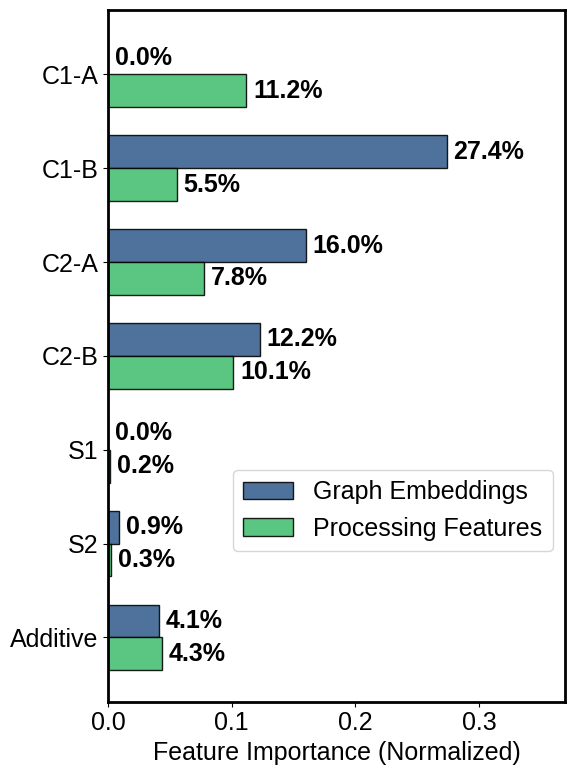

/tmp/ipykernel_55047/103453914.py:182: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(collapsed_shap, collapsed_data, feature_names=collapsed_names, show=False)


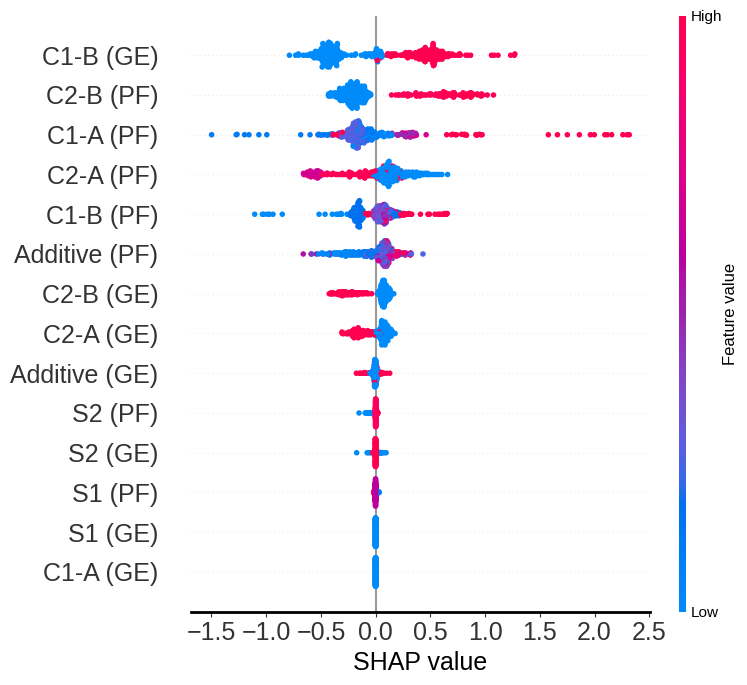

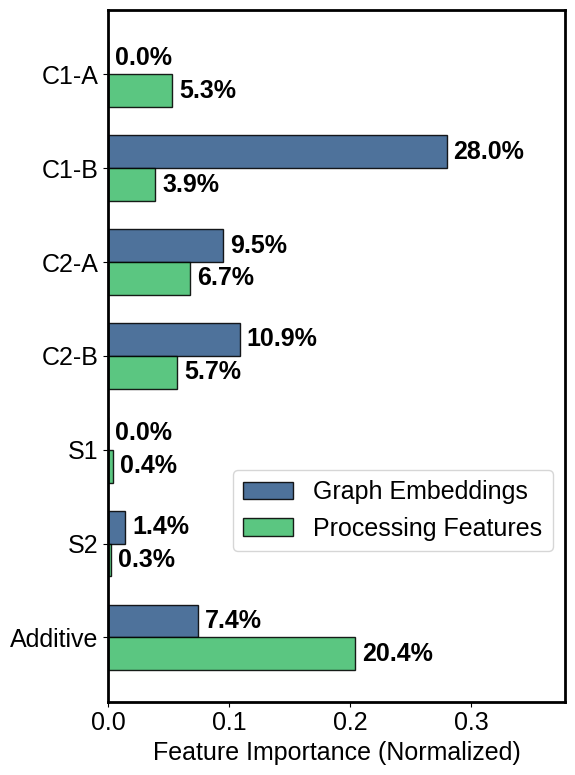

/tmp/ipykernel_55047/103453914.py:182: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(collapsed_shap, collapsed_data, feature_names=collapsed_names, show=False)


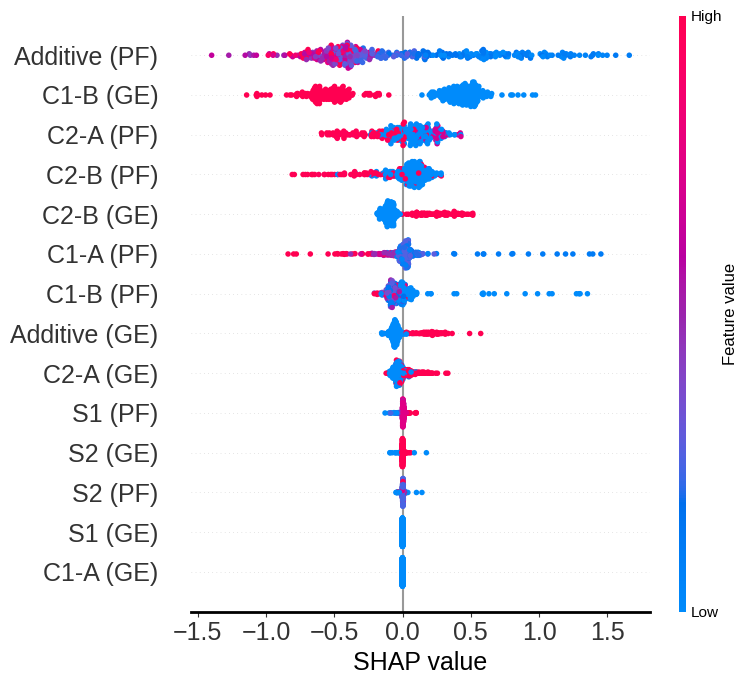

In [39]:
runs_dir = "full_data_runsV2"
all_run_files = os.listdir(runs_dir)
best_model_file = next((f for f in all_run_files if f.startswith("best")), None)
best_model_path = os.path.join(runs_dir, best_model_file)
model = HierarchicalGNN(combined_molecular_graphs,num_atom_feat=num_atom_features,num_edge_feat=num_edge_features,processing_feature_dim=2,num_components=7,hidden_dim=128).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=False))
model.eval()

shap_domain = run_blockwise_shap(
    model        = model,
    loader       = train_loader,
    device       = device,
    target_idx   = 0,           # 0 = Domain, 1 = FWHM
    n_background = 200,
    n_explain    = 500,
    legend_bbox  = (1.0, 0.2)   
)

# ── Run SHAP for FWHM prediction ─────────────────────────────────────────────
shap_fwhm = run_blockwise_shap(
    model        = model,
    loader       = train_loader,
    device       = device,
    target_idx   = 1,           # 1 = FWHM
    n_background = 200,
    n_explain    = 500,
    legend_bbox  = (1.0, 0.2)   
)


In [9]:
def get_uncertainty_mc_dropout(model, data_loader, device, n_passes=20):
    """
    Estimate uncertainty via Monte Carlo Dropout and extract feature embeddings.
    Returns both uncertainty estimates and embeddings for diversity-based selection.
    """
    model.eval()
    
    # Function to enable dropout in eval mode
    def enable_dropout(module):
        if isinstance(module, torch.nn.Dropout) or isinstance(module, torch.nn.Dropout2d):
            module.train()
    
    all_predictions = []
    all_embeddings = []

    for pass_idx in range(n_passes):
        pass_predictions = []
        
        # Enable dropout for this pass
        model.apply(enable_dropout)
        
        for batch_data in data_loader:
            s_idx, node_scalar_feat, _ = batch_data
            s_idx = s_idx.to(device)
            node_scalar_feat = node_scalar_feat.to(device)

            with torch.no_grad():
                # Extract shared features (embeddings) before final towers
                shared_feat = model(s_idx, node_scalar_feat, mc_dropout=False, return_embeddings=True)
                preds = model(s_idx, node_scalar_feat, mc_dropout=False)
            
            pass_predictions.append(preds.cpu().numpy())
            if pass_idx == 0:  # Only collect embeddings once
                all_embeddings.append(shared_feat.cpu().numpy())

        pass_predictions = np.vstack(pass_predictions)
        all_predictions.append(pass_predictions)

    all_predictions = np.array(all_predictions)  # (n_passes, N, 2)
    std_preds = all_predictions.std(axis=0)      # (N, 2)
    total_uncertainty = np.linalg.norm(std_preds, axis=1)  # Euclidean norm across outputs
    
    # Concatenate embeddings across batches
    embeddings = np.vstack(all_embeddings) if all_embeddings else None
    
    # Reset model to eval mode
    model.eval()
    return total_uncertainty, embeddings, all_predictions


def query_samples_uncertainty_ranking(uncertainties, unlabeled_indices, batch_size=5):
    """
    Query samples using simple uncertainty ranking - select top N most uncertain samples.
    This ensures exactly batch_size samples are selected every time.
    """
    if len(uncertainties) == 0:
        return np.array([], dtype=int)
    
    # Get the indices of top batch_size most uncertain samples
    top_k_indices = np.argsort(uncertainties)[-batch_size:][::-1]  # Descending order
    query_indices = unlabeled_indices[top_k_indices]
    
    return query_indices

print("✓ MC Dropout uncertainty and simple uncertainty ranking query function defined")


✓ MC Dropout uncertainty and simple uncertainty ranking query function defined


In [10]:
def run_active_learning(sample_batch_size, max_al_steps, initial_size=10):
    """
    Run active learning with specified batch size and return results.
    """
    print(f"\n{'='*70}")
    print(f"STARTING ACTIVE LEARNING: BATCH SIZE = {sample_batch_size}")
    print(f"{'='*70}")

    if 'train_indices_global' not in globals() or 'test_indices_global' not in globals():
        raise NameError(
            "Global split indices not found. Run the split cell that defines "
            "train_indices_global and test_indices_global first."
        )

    # Use global positional indices from the full dataset to avoid split leakage
    train_indices_local = np.array(train_indices_global, dtype=int).copy()
    test_indices_local = np.array(test_indices_global, dtype=int).copy()

    labeled_indices = np.random.choice(train_indices_local, size=initial_size, replace=False)
    unlabeled_indices = np.setdiff1d(train_indices_local, labeled_indices)

    # Training hyperparameters
    AL_BATCH_SIZE_LOCAL = 32
    EPOCHS_LOCAL = 200
    MC_DROPOUT_PASSES_LOCAL = 20

    # Results tracking
    al_results_local = {
        'iteration': [],
        'train_size': [],
        'train_steps': [],
        'test_mae_domain': [],
        'test_mae_fwhm': [],
        'test_rmse_domain': [],
        'test_rmse_fwhm': [],
        'test_r2_domain': [],
        'test_r2_fwhm': []
    }

    print("Dataset split:")
    print(f"  Total samples: {len(dataset)}")
    print(f"  Train split: {len(train_indices_local)}")
    print(f"  Test split: {len(test_indices_local)}")
    print(f"  Initially labeled: {len(labeled_indices)}")
    print(f"  Unlabeled pool: {len(unlabeled_indices)}")
    print(f"  MAX_AL_STEPS: {max_al_steps} | BATCH: {AL_BATCH_SIZE_LOCAL} | EPOCHS: {EPOCHS_LOCAL}")
    print(f"  SAMPLE_BATCH_SIZE: {sample_batch_size}")
    print("="*70 + "\n")

    # Test loader from global test indices
    test_subset_local = torch.utils.data.Subset(dataset, test_indices_local)
    test_loader_local = DataLoader(test_subset_local, batch_size=AL_BATCH_SIZE_LOCAL, shuffle=False)

    cumulative_steps = 0
    iteration = 0
    final_model_local = None

    while len(unlabeled_indices) > 0 and iteration < max_al_steps:
        print(f"\n--- AL Iteration {iteration} (Train Size: {len(labeled_indices)}) ---")

        # 1) Prepare training data
        train_subset_local = torch.utils.data.Subset(dataset, labeled_indices)
        batch_size = min(AL_BATCH_SIZE_LOCAL, len(labeled_indices))
        drop_last = (len(labeled_indices) % batch_size == 1) and (len(labeled_indices) > batch_size)
        train_loader_local = DataLoader(
            train_subset_local, batch_size=batch_size, shuffle=True, drop_last=drop_last
        )

        if len(labeled_indices) < 2:
            print("Not enough samples for training, skipping iteration.")
            iteration += 1
            continue

        # 2) Train model
        torch.manual_seed(SEED + iteration)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + iteration)

        num_atom_features = 7
        num_edge_features = 3

        model = HierarchicalGNN(
            molecular_graphs, 
            num_atom_features, 
            num_edge_feat=num_edge_features, 
            processing_feature_dim=2, 
            num_components=7,
            hidden_dim=128,
            dropout_rate=0.1
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
        criterion = nn.MSELoss()

        for epoch in range(EPOCHS_LOCAL):
            train_loss = train(
                model, train_loader_local, optimizer, criterion, fwhm_weight=fwhm_weight
            )
            scheduler.step(train_loss)
            if (epoch + 1) % 100 == 0:
                print(f"Epoch {epoch+1}: Train Loss {train_loss:.4f}")

        final_model_local = model

        # Update cumulative training steps
        steps_per_epoch = len(train_loader_local)
        cumulative_steps += steps_per_epoch * EPOCHS_LOCAL

        # 3) Evaluate on test set
        test_loss, preds_orig, targets_orig = evaluate(model, test_loader_local, criterion, fwhm_weight=fwhm_weight)

        mae_domain = mean_absolute_error(targets_orig[:, 0], preds_orig[:, 0])
        mae_fwhm = mean_absolute_error(targets_orig[:, 1], preds_orig[:, 1])
        rmse_domain = np.sqrt(mean_squared_error(targets_orig[:, 0], preds_orig[:, 0]))
        rmse_fwhm = np.sqrt(mean_squared_error(targets_orig[:, 1], preds_orig[:, 1]))
        r2_domain = r2_score(targets_orig[:, 0], preds_orig[:, 0])
        r2_fwhm = r2_score(targets_orig[:, 1], preds_orig[:, 1])

        # Record results
        al_results_local['iteration'].append(iteration)
        al_results_local['train_size'].append(len(labeled_indices))
        al_results_local['train_steps'].append(cumulative_steps)
        al_results_local['test_mae_domain'].append(mae_domain)
        al_results_local['test_mae_fwhm'].append(mae_fwhm)
        al_results_local['test_rmse_domain'].append(rmse_domain)
        al_results_local['test_rmse_fwhm'].append(rmse_fwhm)
        al_results_local['test_r2_domain'].append(r2_domain)
        al_results_local['test_r2_fwhm'].append(r2_fwhm)

        print(
            f"Iter {iteration} — MAE (Domain): {mae_domain:.4f} | MAE (FWHM): {mae_fwhm:.4f} | "
            f"RMSE (Domain): {rmse_domain:.4f} | RMSE (FWHM): {rmse_fwhm:.4f} | "
            f"R2 (Domain): {r2_domain:.4f} | R2 (FWHM): {r2_fwhm:.4f} | "
            f"Cumulative Steps: {cumulative_steps}"
        )

        if len(unlabeled_indices) < sample_batch_size:
            print(f"Not enough samples to continue (need {sample_batch_size}, have {len(unlabeled_indices)}). Stopping.")
            break

        # 4) Selection - Simple uncertainty ranking
        unlabeled_subset_local = torch.utils.data.Subset(dataset, unlabeled_indices)
        uncertainty_batch_size = max(2, AL_BATCH_SIZE_LOCAL)
        unlabeled_loader_local = DataLoader(
            unlabeled_subset_local, batch_size=uncertainty_batch_size, shuffle=False
        )

        print(f"  Computing MC Dropout uncertainty ({MC_DROPOUT_PASSES_LOCAL} passes)...")
        uncertainties, embeddings, _ = get_uncertainty_mc_dropout(
            model, unlabeled_loader_local, device, n_passes=MC_DROPOUT_PASSES_LOCAL
        )

        if len(uncertainties) == 0:
            print("Uncertainty extraction failed. Stopping.")
            break

        # Use simple uncertainty ranking to select exactly sample_batch_size samples
        query_indices = query_samples_uncertainty_ranking(
            uncertainties, unlabeled_indices, batch_size=sample_batch_size
        )
        print(f"  Queried {len(query_indices)} samples")

        # Update pools
        labeled_indices = np.concatenate([labeled_indices, query_indices]).astype(int)
        unlabeled_indices = np.setdiff1d(unlabeled_indices, query_indices)

        iteration += 1

    print(f"\n{'='*70}")
    print(f"ACTIVE LEARNING COMPLETE (Batch Size = {sample_batch_size})")
    print(f"Final labeled pool size: {len(labeled_indices)}")
    print(f"Total iterations completed: {iteration}")
    print(f"{'='*70}\n")

    return al_results_local, final_model_local

# Run AL with batch size 5
al_results_batch5, model_batch5 = run_active_learning(sample_batch_size=5, max_al_steps=113)

# Run AL with batch size 10
al_results_batch10, model_batch10 = run_active_learning(sample_batch_size=10, max_al_steps=57)

print("\n" + "="*70)
print("ALL ACTIVE LEARNING RUNS COMPLETED")
print("="*70)



STARTING ACTIVE LEARNING: BATCH SIZE = 5
Dataset split:
  Total samples: 719
  Train split: 571
  Test split: 143
  Initially labeled: 10
  Unlabeled pool: 561
  MAX_AL_STEPS: 113 | BATCH: 32 | EPOCHS: 200
  SAMPLE_BATCH_SIZE: 5


--- AL Iteration 0 (Train Size: 10) ---
Epoch 100: Train Loss 0.1810
Epoch 200: Train Loss 0.1588
Iter 0 — MAE (Domain): 0.5078 | MAE (FWHM): 0.6164 | RMSE (Domain): 0.7904 | RMSE (FWHM): 0.8047 | R2 (Domain): 0.5143 | R2 (FWHM): 0.2988 | Cumulative Steps: 200
  Computing MC Dropout uncertainty (20 passes)...
  Queried 5 samples

--- AL Iteration 1 (Train Size: 15) ---
Epoch 100: Train Loss 0.2095
Epoch 200: Train Loss 0.1401
Iter 1 — MAE (Domain): 0.4405 | MAE (FWHM): 0.5740 | RMSE (Domain): 0.6087 | RMSE (FWHM): 0.7761 | R2 (Domain): 0.7119 | R2 (FWHM): 0.3477 | Cumulative Steps: 400
  Computing MC Dropout uncertainty (20 passes)...
  Queried 5 samples

--- AL Iteration 2 (Train Size: 20) ---
Epoch 100: Train Loss 0.1283
Epoch 200: Train Loss 0.1560
Iter 2

In [11]:
# Save final model from AL
os.makedirs("AL", exist_ok=True)
if model_batch5 is not None and model_batch10 is not None:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    batch5_model_path = f"AL/gnn_al_model_final_{timestamp}.pt"
    torch.save(model_batch5.state_dict(), batch5_model_path)
    print(f"Final AL model saved to: {batch5_model_path}")

    batch10_model_path = f"AL/gnn_al_model_final_{timestamp}_batch10.pt"
    torch.save(model_batch10.state_dict(), batch10_model_path)
    print(f"Final AL model (batch size 10) saved to: {batch10_model_path}")
else:
    print("No final model to save from AL runs.")

# Save AL results immediately after the loop
results_dir = "AL"
os.makedirs(results_dir, exist_ok=True)

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Save results for batch 5
al_results_path_batch5 = os.path.join(results_dir, f"al_results_gnns_batch5_{timestamp}.json")
with open(al_results_path_batch5, 'w') as f:
    json.dump(al_results_batch5, f, indent=2)
print(f"Active Learning results (batch 5) saved to: {al_results_path_batch5}")

# Save results for batch 10
al_results_path_batch10 = os.path.join(results_dir, f"al_results_gnns_batch10_{timestamp}.json")
with open(al_results_path_batch10, 'w') as f:
    json.dump(al_results_batch10, f, indent=2)
print(f"Active Learning results (batch 10) saved to: {al_results_path_batch10}")

Final AL model saved to: AL/gnn_al_model_final_20260323_142400.pt
Final AL model (batch size 10) saved to: AL/gnn_al_model_final_20260323_142400_batch10.pt
Active Learning results (batch 5) saved to: AL/al_results_gnns_batch5_20260323_142400.json
Active Learning results (batch 10) saved to: AL/al_results_gnns_batch10_20260323_142400.json


Loaded batch size 5 results from al_results_gnns_batch5_20260323_142400.json
Loaded batch size 10 results from al_results_gnns_batch10_20260323_142400.json


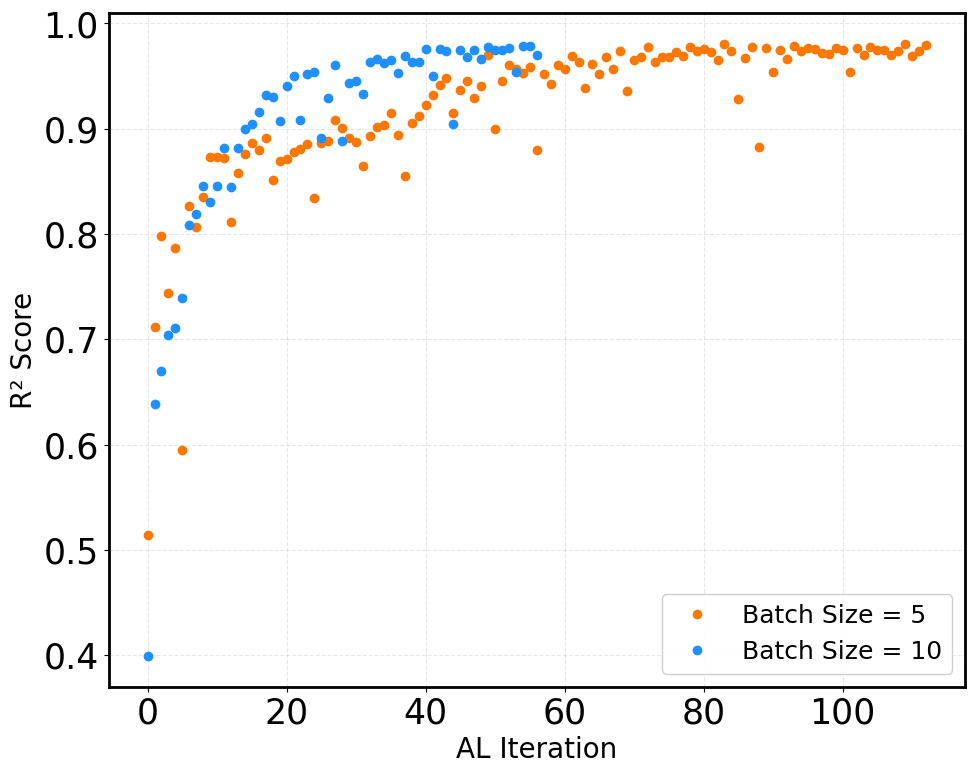

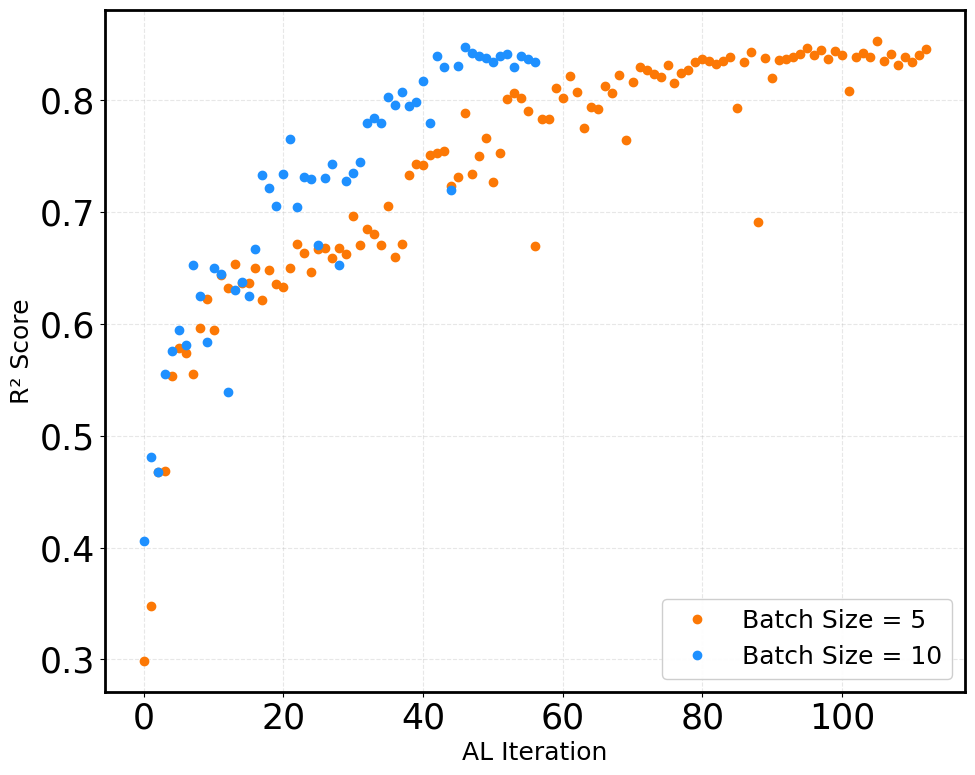

In [12]:
results_dir = "AL"
os.makedirs(results_dir, exist_ok=True)

# Load results for both batch sizes
df_batch5 = None
df_batch10 = None

if os.path.exists(results_dir):
    json_files = [f for f in os.listdir(results_dir) if f.startswith('al_results_gnns_') and f.endswith('.json')]
    if json_files:
        # Separate batch5 and batch10 files
        batch5_files = [f for f in json_files if 'batch5' in f]
        batch10_files = [f for f in json_files if 'batch10' in f]
        
        # Load batch5 (latest)
        if batch5_files:
            batch5_files.sort(key=lambda x: os.path.getmtime(os.path.join(results_dir, x)), reverse=True)
            with open(os.path.join(results_dir, batch5_files[0]), 'r') as f:
                al_results_batch5 = json.load(f)
            df_batch5 = pd.DataFrame(al_results_batch5)
            print(f"Loaded batch size 5 results from {batch5_files[0]}")
        
        # Load batch10 (latest)
        if batch10_files:
            batch10_files.sort(key=lambda x: os.path.getmtime(os.path.join(results_dir, x)), reverse=True)
            with open(os.path.join(results_dir, batch10_files[0]), 'r') as f:
                al_results_batch10 = json.load(f)
            df_batch10 = pd.DataFrame(al_results_batch10)
            print(f"Loaded batch size 10 results from {batch10_files[0]}")
else:
    raise FileNotFoundError("Results directory 'AL' not found.")

if df_batch5 is None and df_batch10 is None:
    print("No batch results loaded.")
else:
    # Set plot settings to match parity plot
    rc('text', usetex=False)
    rc('mathtext', fontset='cm')
    rc('xtick', labelsize=25)
    rc('ytick', labelsize=25)
    rc('axes', labelsize=25, linewidth=2, labelweight='500')
    rc('font', family='sans-serif', size=15, weight='500', style='normal')
    plt.rcParams['axes.spines.right'] = True
    plt.rcParams['axes.spines.top'] = True
    
    # Define colors for each batch size
    color_batch5 =    "#fc7805"
    color_batch10 =   'dodgerblue'

    # --- Figure 1: Domain R2 (Both Batch Sizes) ---
    fig1, ax_domain = plt.subplots(figsize=(10, 8))
    
    # Plot batch size 5
    if df_batch5 is not None and 'test_r2_domain' in df_batch5.columns:
        x_vals_b5 = df_batch5['iteration'].values.astype(float)
        domain_r2_b5 = df_batch5['test_r2_domain'].values
        ax_domain.plot(x_vals_b5, domain_r2_b5, color=color_batch5, linewidth=0, label='Batch Size = 5', marker='o', markersize=6, zorder=2)
    
    # Plot batch size 10
    if df_batch10 is not None and 'test_r2_domain' in df_batch10.columns:
        x_vals_b10 = df_batch10['iteration'].values.astype(float)
        domain_r2_b10 = df_batch10['test_r2_domain'].values
        ax_domain.plot(x_vals_b10, domain_r2_b10, color=color_batch10, linewidth=0, label='Batch Size = 10', marker='o', markersize=6, zorder=2)
    
    #ax_domain.set_title('Domain Spacing R² - AL Learning Curves', fontsize=22, fontweight='bold')
    ax_domain.set_ylabel('R² Score', fontsize=20)
    ax_domain.set_xlabel('AL Iteration', fontsize=20)
    ax_domain.legend(fontsize=18, loc='lower right', framealpha=0.95)
    ax_domain.grid(True, alpha=0.3, linestyle='--')
    ax_domain.set_axisbelow(True)

    plt.tight_layout()

    # --- Figure 2: FWHM R2 (Both Batch Sizes) ---
    fig2, ax_fwhm = plt.subplots(figsize=(10, 8))
    
    # Plot batch size 5
    if df_batch5 is not None and 'test_r2_fwhm' in df_batch5.columns:
        x_vals_b5 = df_batch5['iteration'].values.astype(float)
        fwhm_r2_b5 = df_batch5['test_r2_fwhm'].values
        ax_fwhm.plot(x_vals_b5, fwhm_r2_b5, color=color_batch5, linewidth=0, label='Batch Size = 5', marker='o', markersize=6, zorder=2)
    
    # Plot batch size 10
    if df_batch10 is not None and 'test_r2_fwhm' in df_batch10.columns:
        x_vals_b10 = df_batch10['iteration'].values.astype(float)
        fwhm_r2_b10 = df_batch10['test_r2_fwhm'].values
        ax_fwhm.plot(x_vals_b10, fwhm_r2_b10, color=color_batch10, linewidth=0, label='Batch Size = 10', marker='o', markersize=6, zorder=2)
    
    #ax_fwhm.set_title('FWHM R² - AL Learning Curves', fontsize=22, fontweight='bold')
    ax_fwhm.set_ylabel('R² Score', fontsize=18)
    ax_fwhm.set_xlabel('AL Iteration', fontsize=18)
    ax_fwhm.legend(fontsize=18, loc='lower right', framealpha=0.95)
    ax_fwhm.grid(True, alpha=0.3, linestyle='--')
    ax_fwhm.set_axisbelow(True)

    plt.tight_layout()